In [1]:
# Passo A: Garante que as bibliotecas visuais estão instaladas (roda apenas se necessário)
try:
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
except ImportError:
    print("Instalando bibliotecas necessárias para os gráficos...")
    %pip install pandas numpy matplotlib seaborn openpyxl
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

import os
sns.set_theme(style="whitegrid")

# Passo B: Define o caminho do arquivo Gold
caminho_gold = os.path.join("data", "gold", "base_consolidada_municipal_2022.csv")

# Passo C: Carrega e exibe os dados
try:
    df = pd.read_csv(caminho_gold)
    print("🚀 Sucesso! Base municipal carregada.")
    print(f"Total de Municípios: {df.shape[0]} | Total de Indicadores: {df.shape[1]}\n")
    
    # Exibe as primeiras 5 linhas da tabela
    display(df.head())
except FileNotFoundError:
    print(f"❌ Erro: Não encontrei o arquivo em: {caminho_gold}")
    print("Verifique se o arquivo .csv realmente está dentro da pasta data/gold/")

Instalando bibliotecas necessárias para os gráficos...



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl (9.8 MB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.3 MB 991.0 kB/s eta 0:00:13
    --------------------------------------- 0.2/12.3 MB 1.5 MB/s eta 0:00:0

,ano,co_uf,sg_uf,co_municipio,no_municipio,nascidos_vivos,obitos_infantis,taxa_mortalidade_infantil,co_regiao_pais,regiao_pais,...,taxa_de_terceirizacao_de_varredores,taxa_de_terceirizacao_de_varricao,custo_unitario_da_varricao,produtividade_media_do_varredores,taxa_de_varredores_por_habitante_urbano,incidencia_do_custo_da_varricao_no_custo_total_do_manejo,incidencia_de_varredores_no_total_de_empregados_no_manejo,extensao_total_anual_varrida_per_capita,taxa_de_capinadores_por_habitante_urbano,relacao_de_capinadores_no_total_de_empregados_no_manejo
0,2022,29,BA,290010,ABAIRA,54.0,1.0,18.518519,2,Nordeste,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,29,BA,290030,ACAJUTIBA,156.0,2.0,12.820513,2,Nordeste,...,NaN,NaN,NaN,NaN,NaN,33.32,NaN,NaN,NaN,NaN
2,2022,29,BA,290035,ADUSTINA,146.0,3.0,20.547945,2,Nordeste,...,100.0,NaN,NaN,NaN,NaN,71.26,38.46,NaN,NaN,38.46
3,2022,29,BA,290040,AGUA FRIA,145.0,2.0,13.793103,2,Nordeste,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,29,BA,290050,ERICO CARDOSO,118.0,2.0,16.949153,2,Nordeste,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


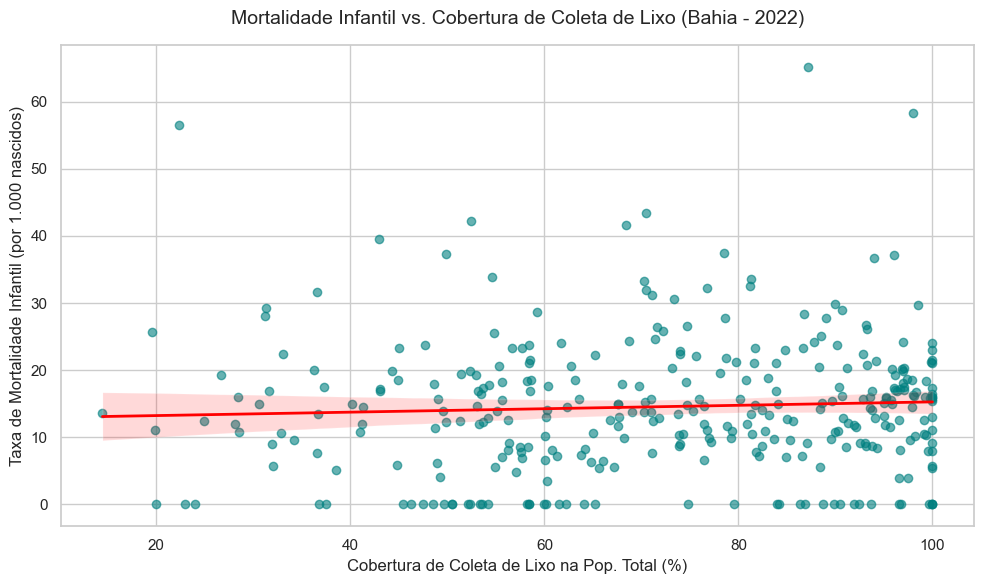

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define o tamanho da imagem do gráfico
plt.figure(figsize=(10, 6))

# Cria o gráfico cruzando a Cobertura de Lixo (X) com a Mortalidade Infantil (Y)
sns.regplot(
    data=df, 
    x="tx_cobertura_da_coleta_rdo_em_relacao_a_pop_total", 
    y="taxa_mortalidade_infantil",
    scatter_kws={'alpha':0.6, 'color': 'teal'}, # Pontos em azul-esverdeado
    line_kws={'color': 'red', 'linewidth': 2}     # Linha de tendência em vermelho
)

# Adiciona títulos fáceis de ler
plt.title("Mortalidade Infantil vs. Cobertura de Coleta de Lixo (Bahia - 2022)", fontsize=14, pad=15)
plt.xlabel("Cobertura de Coleta de Lixo na Pop. Total (%)", fontsize=12)
plt.ylabel("Taxa de Mortalidade Infantil (por 1.000 nascidos)", fontsize=12)

# Mostra o gráfico na tela
plt.tight_layout()
plt.show()

In [6]:
# Filtra apenas os municípios com taxa de mortalidade muito crítica (acima de 35)
outliers = df[df['taxa_mortalidade_infantil'] > 35]

# Mostra o nome, a mortalidade e a cobertura de lixo deles
outliers[['no_municipio', 'taxa_mortalidade_infantil', 'tx_cobertura_da_coleta_rdo_em_relacao_a_pop_total']].sort_values(by='taxa_mortalidade_infantil', ascending=False)

,no_municipio,taxa_mortalidade_infantil,tx_cobertura_da_coleta_rdo_em_relacao_a_pop_total
87,CRAVOLANDIA,65.217391,87.20
184,LENCOIS,58.252427,98.00
21,AURELINO LEAL,56.497175,22.36
37,BONINAL,43.478261,70.42
261,RIO DO PIRES,42.253521,52.40
133,IPUPIARA,41.666667,68.44
194,MANSIDAO,39.473684,42.96
76,CONCEICAO DO ALMEIDA,37.500000,78.52
12,ANGICAL,37.234043,49.88
316,UBAITABA,37.190083,95.99


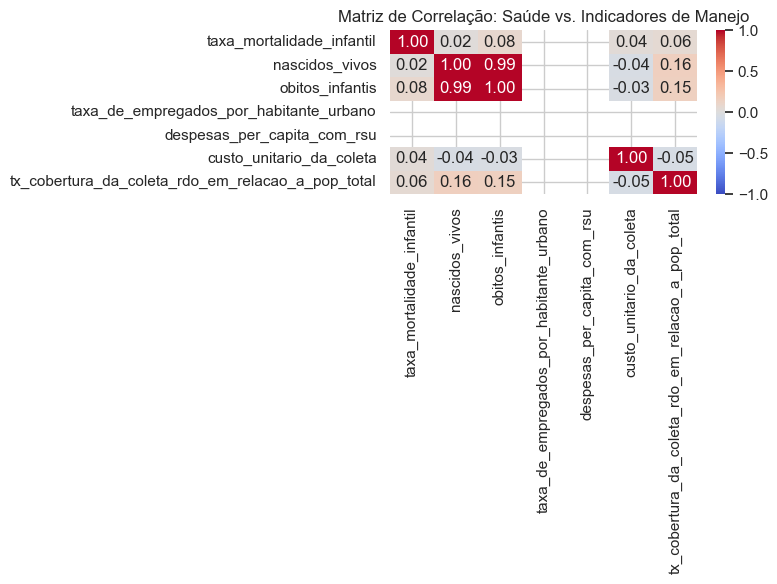

In [7]:
# Selecionando colunas numéricas de infraestrutura para cruzar com a mortalidade
colunas_analise = [
    'taxa_mortalidade_infantil',
    'nascidos_vivos',
    'obitos_infantis',
    'taxa_de_empregados_por_habitante_urbano',
    'despesas_per_capita_com_rsu',
    'custo_unitario_da_coleta',
    'tx_cobertura_da_coleta_rdo_em_relacao_a_pop_total'
]

# Calcula a correlação entre elas
matriz_corr = df[colunas_analise].corr()

# Plota o gráfico de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação: Saúde vs. Indicadores de Manejo")
plt.tight_layout()
plt.show()

In [8]:
import os
import pandas as pd

# Define o caminho para a base específica de água e esgoto
caminho_agua_esgoto = os.path.join("data", "gold", "base_snis_agua_esgoto_2022.csv")

try:
    df_agua_esgoto = pd.read_csv(caminho_agua_esgoto)
    print("🚀 Sucesso! Base de Água e Esgoto carregada.")
    print(f"Total de linhas: {df_agua_esgoto.shape[0]} | Total de colunas: {df_agua_esgoto.shape[1]}\n")
    
    # Mostra todas as colunas disponíveis para a nossa nova investigação
    print("--- 📋 Colunas disponíveis nesta base ---")
    print(list(df_agua_esgoto.columns))
    
except FileNotFoundError:
    print(f"❌ Erro: Não achei o arquivo no caminho: {caminho_agua_esgoto}")

🚀 Sucesso! Base de Água e Esgoto carregada.
Total de linhas: 405 | Total de colunas: 11

--- 📋 Colunas disponíveis nesta base ---
['co_uf', 'sg_uf', 'co_municipio', 'tx_atendimento_total_agua', 'tx_atendimento_urbano_agua', 'tx_atendimento_urbano_esgoto', 'tx_coleta_esgoto', 'tx_tratamento_esgoto', 'consumo_per_capita_agua', 'idx_conformidade_coliformes', 'no_prestador_servico_ae']


🔗 Tabelas unificadas! Temos agora 324 municípios com dados de Saúde + Água + Esgoto.

📊 --- Nova Matriz de Correlação ---


,taxa_mortalidade_infantil,tx_atendimento_total_agua,tx_coleta_esgoto,idx_conformidade_coliformes
taxa_mortalidade_infantil,1.000000,0.067440,0.131632,0.011803
tx_atendimento_total_agua,0.067440,1.000000,0.262614,0.059764
tx_coleta_esgoto,0.131632,0.262614,1.000000,0.048894
idx_conformidade_coliformes,0.011803,0.059764,0.048894,1.000000


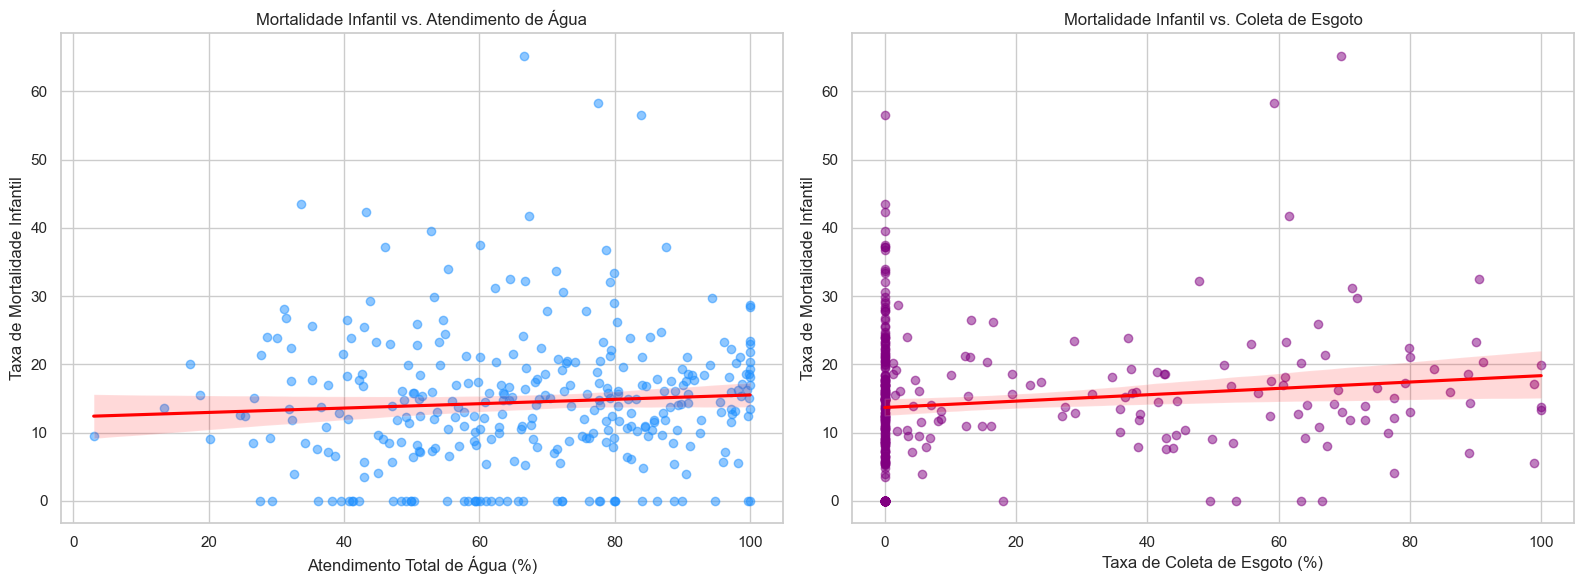

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cruza a base de mortalidade (df) com a de água/esgoto (df_agua_esgoto) usando o código do município
df_consolidado_novo = pd.merge(
    df[['co_municipio', 'no_municipio', 'taxa_mortalidade_infantil']], 
    df_agua_esgoto[['co_municipio', 'tx_atendimento_total_agua', 'tx_coleta_esgoto', 'idx_conformidade_coliformes']], 
    on='co_municipio', 
    how='inner'
)

print(f"🔗 Tabelas unificadas! Temos agora {df_consolidado_novo.shape[0]} municípios com dados de Saúde + Água + Esgoto.\n")

# 2. Mostra a nova Matriz de Correlação na tela
print("📊 --- Nova Matriz de Correlação ---")
nova_corr = df_consolidado_novo[['taxa_mortalidade_infantil', 'tx_atendimento_total_agua', 'tx_coleta_esgoto', 'idx_conformidade_coliformes']].corr()
display(nova_corr)

# 3. Plota os gráficos para inspeção visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Mortalidade vs Água
sns.regplot(
    data=df_consolidado_novo, 
    x="tx_atendimento_total_agua", 
    y="taxa_mortalidade_infantil", 
    ax=axes[0], 
    scatter_kws={'alpha':0.5, 'color': 'dodgerblue'}, 
    line_kws={'color': 'red'}
)
axes[0].set_title("Mortalidade Infantil vs. Atendimento de Água")
axes[0].set_xlabel("Atendimento Total de Água (%)")
axes[0].set_ylabel("Taxa de Mortalidade Infantil")

# Gráfico 2: Mortalidade vs Esgoto
sns.regplot(
    data=df_consolidado_novo, 
    x="tx_coleta_esgoto", 
    y="taxa_mortalidade_infantil", 
    ax=axes[1], 
    scatter_kws={'alpha':0.5, 'color': 'purple'}, 
    line_kws={'color': 'red'}
)
axes[1].set_title("Mortalidade Infantil vs. Coleta de Esgoto")
axes[1].set_xlabel("Taxa de Coleta de Esgoto (%)")
axes[1].set_ylabel("Taxa de Mortalidade Infantil")

plt.tight_layout()
plt.show()

In [10]:
# Agrupa os dados por Macrorregião de Saúde e calcula a média dos indicadores
analise_regional = df.groupby('macrorregiao_de_saude').agg(
    total_municipios=('no_municipio', 'count'),
    media_mortalidade=('taxa_mortalidade_infantil', 'mean'),
    total_nascidos=('nascidos_vivos', 'sum'),
    total_obitos=('obitos_infantis', 'sum')
).reset_index()

# Calcula a taxa de mortalidade real agregada da região inteira (para evitar distorções de cidades pequenas)
analise_regional['taxa_mortalidade_real_regiao'] = (analise_regional['total_obitos'] / analise_regional['total_nascidos']) * 1000

# Ordena da região mais crítica para a menos crítica
analise_regional.sort_values(by='taxa_mortalidade_real_regiao', ascending=False)

,macrorregiao_de_saude,total_municipios,media_mortalidade,total_nascidos,total_obitos,taxa_mortalidade_real_regiao
3,LESTE - (NRS - SALVADOR),44,15.276634,47245.0,783.0,16.573182
8,SUL (NBS - ILHEUS),52,14.329613,15344.0,254.0,16.553702
4,NORDESTE (NRS - ALAGOINHAS),26,15.131218,8089.0,129.0,15.947583
5,NORTE - (NRS - JUAZEIRO),25,17.239758,13373.0,208.0,15.553728
6,OESTE (NBS - BARREIRAS),30,16.735114,12801.0,186.0,14.530115
1,CENTRO-LESTE (NRS - FEIRA SANTANA),59,14.250617,24009.0,344.0,14.327960
7,SUDOESTE (NBS - VITORIA CONQUISTA),54,13.296158,16899.0,242.0,14.320374
0,CENTRO - NORTE (NRS - JACOBINA),26,13.240438,7513.0,106.0,14.108878
2,EXTREMO SUL (NRS - TEIXEIRA FREITAS),16,11.689870,11156.0,149.0,13.356042


In [13]:
%pip install scipy

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 320.0 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 461.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/36.5 MB 2.0 MB/s eta 0:00:19
   ---------------------------------------- 0.2/36.5 MB 2.2 MB/s eta 0:00:17
   ---------------------------------------- 0.4/36.5 MB 3.1 MB/s eta 0:00:12
    --------------------------------------- 0.6/36.5 MB 3.6 MB/s eta 0:00:10
   - -------------------------------------- 1.1/36.5 MB 5.0 MB/s eta 0:00:08
   - -------------------------------------- 1.7/36.5 MB 6.2 MB/s eta 0:00:06
   -- ------------------------------------- 2.2/36.5 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 2.8/36.5 MB 7.4 MB/s eta 0:00:05
  


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from scipy.stats import spearmanr

# Calcula a correlação de Spearman e o p-valor entre Lixo e Mortalidade
corr_lixo, p_val_lixo = spearmanr(df['tx_cobertura_da_coleta_rdo_em_relacao_a_pop_total'], df['taxa_mortalidade_infantil'], nan_policy='omit')

print("🔬 --- TESTE DE HIPÓTESE ACADÊMICO ---")
print(f"Correlação de Spearman: {corr_lixo:.4f}")
print(f"P-Valor: {p_val_lixo:.4f}")

if p_val_lixo < 0.05:
    print("\n✅ O resultado é estatisticamente significante (p < 0.05). A relação existe de fato.")
else:
    print("\n❌ O resultado NÃO é estatisticamente significante (p >= 0.05). A relação observada pode ser fruto do acaso.")

🔬 --- TESTE DE HIPÓTESE ACADÊMICO ---
Correlação de Spearman: 0.0781
P-Valor: 0.1556

❌ O resultado NÃO é estatisticamente significante (p >= 0.05). A relação observada pode ser fruto do acaso.


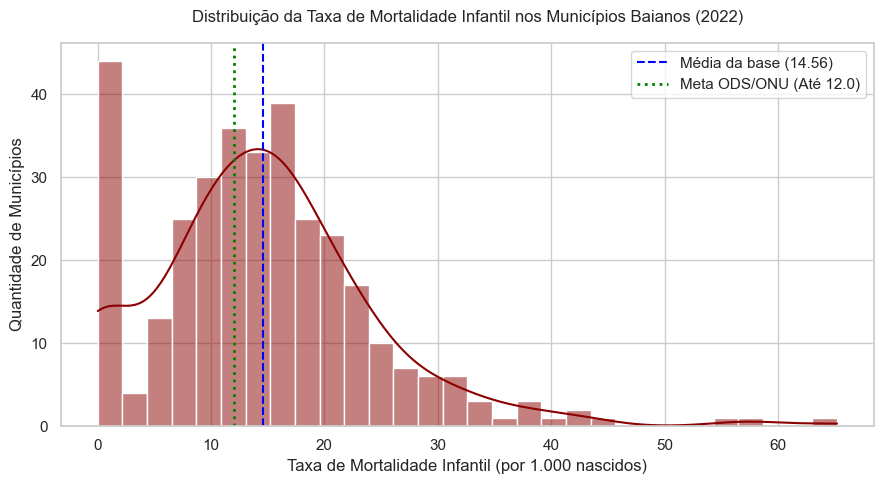

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# Cria o gráfico de distribuição
sns.histplot(df['taxa_mortalidade_infantil'], kde=True, color='darkred', bins=30)

# Linhas de referência acadêmica (Metas da ONU/OMS para mortalidade infantil)
plt.axvline(df['taxa_mortalidade_infantil'].mean(), color='blue', linestyle='--', label=f"Média da base ({df['taxa_mortalidade_infantil'].mean():.2f})")
plt.axvline(12.0, color='green', linestyle=':', linewidth=2, label="Meta ODS/ONU (Até 12.0)")

plt.title("Distribuição da Taxa de Mortalidade Infantil nos Municípios Baianos (2022)", fontsize=12, pad=15)
plt.xlabel("Taxa de Mortalidade Infantil (por 1.000 nascidos)")
plt.ylabel("Quantidade de Municípios")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import spearmanr

# Testa se cidades maiores ou menores têm taxas de mortalidade sistematicamente diferentes
corr_pop, p_val_pop = spearmanr(df['populacao_ibge_2022'], df['taxa_mortalidade_infantil'], nan_policy='omit')

print("👥 --- ANÁLISE DE ESCALA POPULACIONAL ---")
print(f"Correlação de Spearman com População: {corr_pop:.4f}")
print(f"P-Valor: {p_val_pop:.4f}")

👥 --- ANÁLISE DE ESCALA POPULACIONAL ---
Correlação de Spearman com População: 0.1984
P-Valor: 0.0003


C:\Users\pedro\AppData\Local\Temp\ipykernel_16052\3242439685.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


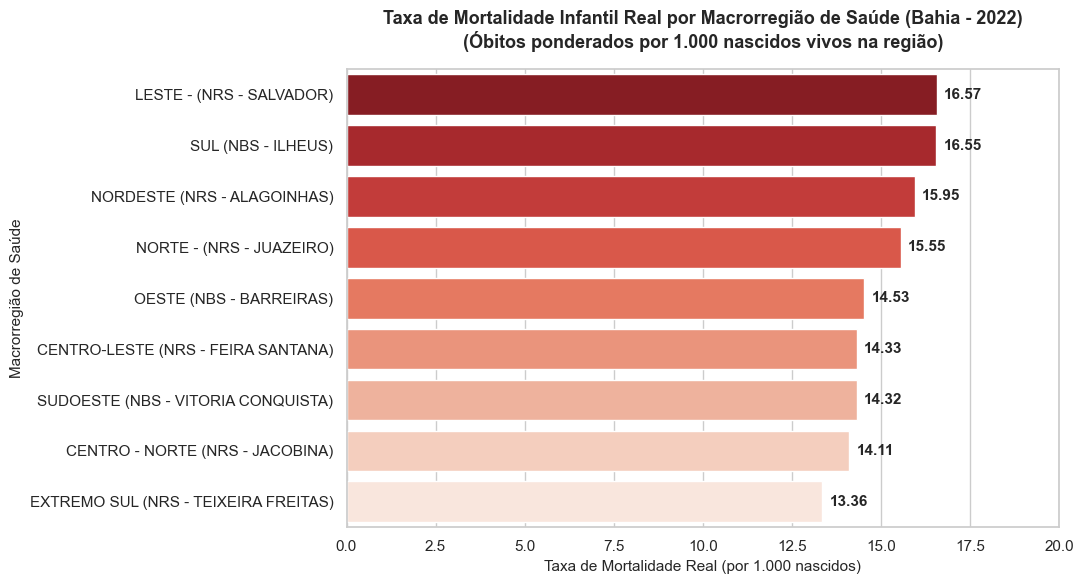

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que os dados regionais estão ordenados pela taxa real
analise_regional_grafico = analise_regional.sort_values(by='taxa_mortalidade_real_regiao', ascending=False)

plt.figure(figsize=(11, 6))

# Cria o gráfico de barras usando uma paleta de cores (da mais crítica para a mais suave)
sns.barplot(
    data=analise_regional_grafico,
    x='taxa_mortalidade_real_regiao',
    y='macrorregiao_de_saude',
    palette='Reds_r' # Degradê de vermelho (mais escuro = maior mortalidade)
)

# Adiciona os valores exatos na ponta de cada barra para facilitar a leitura do professor
for index, value in enumerate(analise_regional_grafico['taxa_mortalidade_real_regiao']):
    plt.text(value + 0.2, index, f"{value:.2f}", va='center', fontsize=11, fontweight='bold')

# Customização acadêmica do gráfico
plt.title("Taxa de Mortalidade Infantil Real por Macrorregião de Saúde (Bahia - 2022)\n(Óbitos ponderados por 1.000 nascidos vivos na região)", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Taxa de Mortalidade Real (por 1.000 nascidos)", fontsize=11)
plt.ylabel("Macrorregião de Saúde", fontsize=11)
plt.xlim(0, 20) # Dá um espaço na direita para o texto não cortar

plt.tight_layout()
plt.show()

In [18]:
# Vamos calcular a média de consultas de pré-natal nas cidades com maior mortalidade
# Verifique se o seu df possui a coluna 'tx_7_ou_mais_consultas_prenatal' ou similar. 
# Caso as colunas tenham nomes diferentes, usaremos as colunas de óbitos brutos para um diagnóstico rápido.

print("🔍 --- DIAGNÓSTICO PARA PLANO DE AÇÃO ---")
# Filtra as 20 cidades com maior taxa de mortalidade e vê o volume de óbitos concentrados nelas
top_criticas = df.sort_values(by='taxa_mortalidade_infantil', ascending=False).head(20)

total_obitos_criticos = top_criticas['obitos_infantis'].sum()
total_nascidos_criticos = top_criticas['nascidos_vivos'].sum()
taxa_grupo_critico = (total_obitos_criticos / total_nascidos_criticos) * 1000

print(f"As 20 cidades mais críticas respondem por um total de {total_obitos_criticos} óbitos.")
print(f"A taxa de mortalidade combinada apenas desse grupo isolado é de {taxa_grupo_critico:.2f} por mil.")
print("\n💡 Recomendação Baseada em Dados: Intervenção direta com foco em Atenção Básica e Pré-Natal neste grupo de municípios.")

🔍 --- DIAGNÓSTICO PARA PLANO DE AÇÃO ---
As 20 cidades mais críticas respondem por um total de 110.0 óbitos.
A taxa de mortalidade combinada apenas desse grupo isolado é de 37.49 por mil.

💡 Recomendação Baseada em Dados: Intervenção direta com foco em Atenção Básica e Pré-Natal neste grupo de municípios.
